In [6]:
# libraries for part 1
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
import re
import sys

pd.set_option('display.max_columns', 200)
plt.style.use("ggplot")

# Libraries for part 2
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# libraries part bert
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, logging

import os
import gc; gc.enable()
from IPython.display import clear_output

In [7]:
df = pd.read_csv('/kaggle/input/datasets/daniellovespancakes/fake-news-cased-200k-sample/fake_news_uncased_sample_200k.xls').iloc[:,1:]
df['content'] = df['content'].str.replace('\n','').str.replace('\t','').astype('str')
df = df.rename(columns={'content':'title'})

x,y = df['title'], df['isfake']
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, stratify=y, random_state=1000)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=1000)

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

del df
gc.collect();

(160000,)
(20000,)
(20000,)


In [8]:
class TitleDataset(Dataset):
    def __init__(self, x, y, tokenizer, size=128):
        self.encodings = tokenizer(
            list(x),
            add_special_tokens = True,
            padding = 'max_length',
            max_length = size,
            truncation = True,
        )
        self.applies = y
        print('dataset initialized!')

    def __getitem__(self, idx):
        item = {k:torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item['isfake'] = torch.tensor(self.applies.iloc[idx]).float()
        return item

    def __len__(self):
        return len(self.applies)

# roberta encoder/model
class RobertaRegressor(nn.Module):
    def __init__(self, _pretrained_model='roberta-base'):
        super().__init__()
        os.environ['TOKENIZERS_PARALLELISM'] = 'true'
        
        # tokenizer-encoder
        self.config = AutoConfig.from_pretrained(_pretrained_model)
        self.encoder = AutoModel.from_pretrained(_pretrained_model, config=self.config)
        self.tokenizer = AutoTokenizer.from_pretrained(_pretrained_model)
        
        clear_output()
        print('model initialized!')

        # model
        self.fc1 = nn.Linear(2*self.config.hidden_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 256)
        self.fc4 = nn.Linear(256, 16)
        self.fc5 = nn.Linear(16, 1)
        self.do1 = nn.Dropout(0.5)
        self.do2 = nn.Dropout(0.35)
        self.do3 = nn.Dropout(0.2)
        self.do4 = nn.Dropout(0.2)

    def max_mean_pooling(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_layer = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(last_layer.size()).float()
        
        mean_vectors = (last_layer * mask).sum(1) / mask.sum(1)
        
        last_layer[mask == 0] = -1e9
        max_vectors,_ = torch.max(last_layer, 1)

        vectors = torch.cat((mean_vectors, max_vectors), 1)
        return vectors
        
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        x = self.max_mean_pooling(input_ids, attention_mask)
        x = self.do1(F.relu(self.fc1(x)))
        x = self.do2(F.relu(self.fc2(x)))
        x = self.do3(F.relu(self.fc3(x)))
        x = self.do4(F.relu(self.fc4(x)))
        x = self.fc5(x)
        return x.float()

    def predict(self, outputs):
        return (outputs > 0).float().squeeze(-1)

In [9]:
# initialization
model = RobertaRegressor(_pretrained_model='distilbert-base-cased')
losses, avg_losses, val_f1s = [],[],[]
jdx = 0

dataset = TitleDataset(x_train, y_train, model.tokenizer)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

val_dataset = TitleDataset(x_val, y_val, model.tokenizer)
val_loader = DataLoader(val_dataset, batch_size=32)

model initialized!
dataset initialized!
dataset initialized!


Using device cuda
Training on 160000 samples, validating on 20000 samples
Epoch: 3/3, Batch: 2500/2500, Loss: 0.0342, Avg: 0.1415    
Best Validation Score: 0.9192


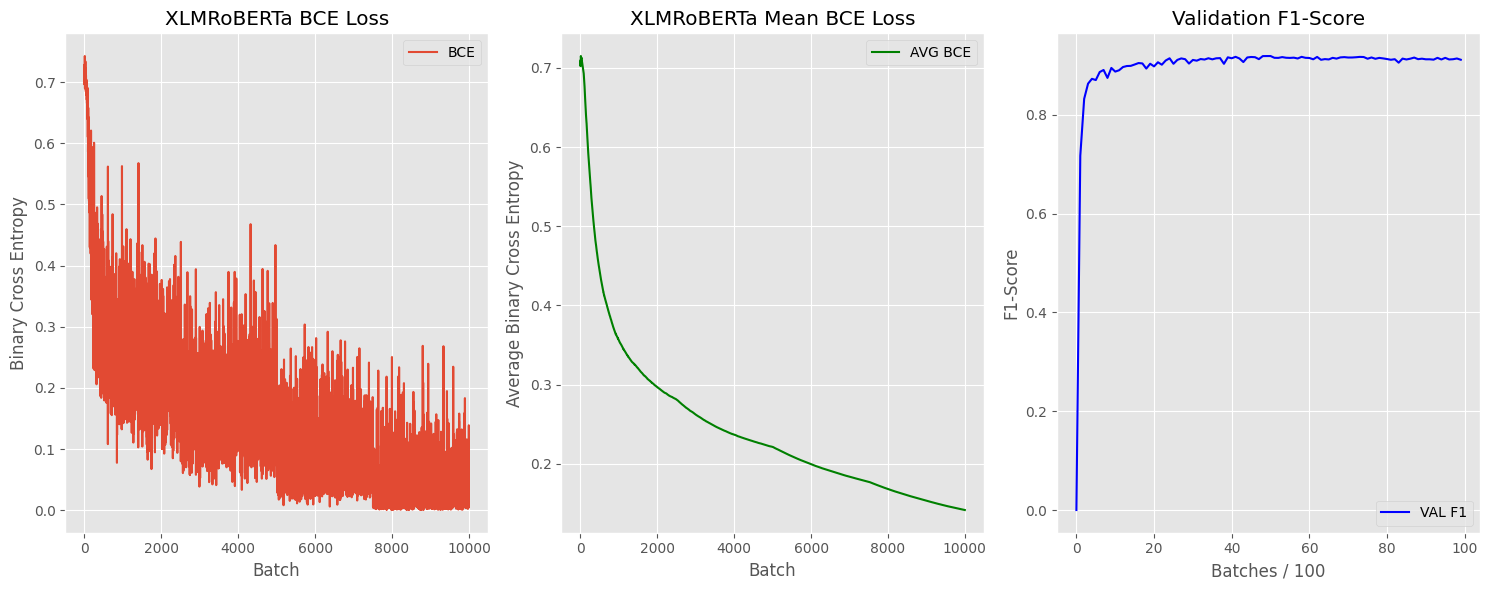

In [31]:
# training loop
lr = 2e-5
epsilon = 1e-6
weight_decay = 0.01

no_decay = ['bias','LayerNorm.weight']
optimizer_grouped_parameters = [
{"params": [p for n, p in model.encoder.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": weight_decay, "lr": lr},
{"params": [p for n, p in model.encoder.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0, "lr": lr},
{'params': model.fc1.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc2.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc3.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc4.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc5.parameters(), 'lr': lr, 'weight_decay': weight_decay}
]

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    optimizer_grouped_parameters,
    lr=lr,
    eps=epsilon,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device {}'.format(device))

print(f'Training on {x_train.shape[0]} samples, validating on {x_val.shape[0]} samples')

model.to(device)
scaler = torch.amp.GradScaler('cuda')

epochs = 3
for e in range(epochs):
    # batches
    for idx,batch in enumerate(loader):
        # tokenization
        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        labels = batch['isfake'].unsqueeze(-1).to(device)

        # optimization
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            preds = model(**inputs)
            loss = criterion(preds, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
            
        # tracking
        losses.append(loss.item())
        avg_losses.append(np.mean(losses))
        sys.stdout.write(f'\rEpoch: {e+1}/{epochs}, Batch: {idx+1}/{len(loader)}, Loss: {loss.item():.4f}, Avg: {np.mean(losses):.4f}    ')

        if jdx % 100 == 0:
            with torch.no_grad():
                    total_val_preds, total_val_labels = [],[]
                    for batch in val_loader:
                        # tokenization
                        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
                        labels = batch['isfake'].unsqueeze(-1).to(device)
                    
                        total_val_preds += model.predict(model(**inputs)).squeeze(-1).cpu().numpy().tolist()
                        total_val_labels += labels.squeeze(-1).cpu().numpy().tolist()
        
                    val_f1s.append(f1_score(total_val_preds, total_val_labels))

        jdx += 1

print("\nBest Validation Score: {:.4f}".format(max(val_f1s)))


# plot loss progression
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.plot(losses, label='BCE')
plt.xlabel('Batch')
plt.ylabel('Binary Cross Entropy')
plt.title('XLMRoBERTa BCE Loss')
plt.legend()
plt.subplot(1,3,2)
plt.plot(avg_losses, label='AVG BCE', color='green')
plt.xlabel('Batch')
plt.ylabel('Average Binary Cross Entropy')
plt.title('XLMRoBERTa Mean BCE Loss')
plt.legend()
plt.tight_layout()
plt.subplot(1,3,3)
plt.plot(val_f1s, label='VAL F1', color='blue')
plt.xlabel('Batches / 100')
plt.ylabel('F1-Score')
plt.title('Validation F1-Score')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# save
torch.save(model.state_dict(), "distilbert_model__1.pth")

# # load
# model = RobertaRegressor(_pretrained_model='distilbert-base-cased')
# model.load_state_dict(torch.load("distilbert_model__1.pth"))
# model.eval()

In [33]:
liar_val = pd.read_csv('/kaggle/input/datasets/daniellovespancakes/liar-validation/validation.csv').iloc[:,[1,2]]
liar_val.columns = ['isfake','title']
liar_val

,isfake,title
0,pants-fire,"When Obama was sworn into office, he DID NOT u..."
1,false,Says Having organizations parading as being so...
2,half-true,Says nearly half of Oregons children are poor.
3,half-true,On attacks by Republicans that various program...
4,false,Says when armed civilians stop mass shootings ...
...,...,...
1278,half-true,"For the first time in more than a decade, impo..."
1279,mostly-true,Says Donald Trump has bankrupted his companies...
1280,true,"John McCain and George Bush have ""absolutely n..."
1281,false,A new poll shows 62 percent support the presid...


In [34]:
real_labels = ['barely-true','half-true','mostly-true','true']
fake_labels = ['false','pants-fire']

liar_val['isfake'] = liar_val['isfake'].apply(lambda x : 0 if x in real_labels else 1)
liar_val

,isfake,title
0,1,"When Obama was sworn into office, he DID NOT u..."
1,1,Says Having organizations parading as being so...
2,0,Says nearly half of Oregons children are poor.
3,0,On attacks by Republicans that various program...
4,1,Says when armed civilians stop mass shootings ...
...,...,...
1278,0,"For the first time in more than a decade, impo..."
1279,0,Says Donald Trump has bankrupted his companies...
1280,0,"John McCain and George Bush have ""absolutely n..."
1281,1,A new poll shows 62 percent support the presid...


In [35]:
liar_x_val, liar_y_val = liar_val['title'], liar_val['isfake']

liar_val_dataset = TitleDataset(liar_x_val, liar_y_val, model.tokenizer)
liar_val_loader = DataLoader(liar_val_dataset, batch_size=32)

with torch.no_grad():
    total_val_preds, total_val_labels = [],[]
    for batch in liar_val_loader:
        # tokenization
        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        labels = batch['isfake'].unsqueeze(-1).to(device)
    
        total_val_preds += model.predict(model(**inputs)).squeeze(-1).cpu().numpy().tolist()
        total_val_labels += labels.squeeze(-1).cpu().numpy().tolist()

print(accuracy_score(total_val_preds, total_val_labels))
print(f1_score(total_val_preds, total_val_labels))
print(classification_report(total_val_preds, total_val_labels))

dataset initialized!
0.5409197194076384
0.3078730904817861
              precision    recall  f1-score   support

         0.0       0.62      0.69      0.66       811
         1.0       0.35      0.28      0.31       472

    accuracy                           0.54      1283
   macro avg       0.48      0.49      0.48      1283
weighted avg       0.52      0.54      0.53      1283



In [ ]:
# read in data
df_test = pd.read_csv('/kaggle/input/datasets/daniellovespancakes/temporaryable-1/temp.csv').iloc[20000:25000,1:]
df_test

In [ ]:
test_example = pd.DataFrame({'isfake':[1], 'title':['isreal declares random goat as the 1234 new prime minister of chicago']})

df_test_with_example = pd.concat([df_test, test_example], axis=0)
df_test_with_example.tail()

In [ ]:
testset = TitleDataset(df_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=0)

with torch.no_grad():
    losses = []
    accs = []
    f1s = []
    total_preds = []
    total_labels = []
    for idx,(titles,labels) in enumerate(testloader):
        inputs = model.tokenizer(list(titles), padding=True, truncation=True, max_length=64, return_tensors='pt')
        inputs = {k:v.to(device) for k,v in inputs.items()}

        preds = model.forward(inputs)
        loss = criterion(preds, labels.float().unsqueeze(-1).to(device))

        pred_labels = (preds > 0).float().squeeze(-1)

        total_labels += [int(l) for l in labels]
        total_preds += [int(p) for p in pred_labels]

        acc = float((pred_labels == labels.to(device)).float().mean())
        f1 = f1_score(pred_labels.cpu().numpy(), labels.to(device).cpu().numpy())

        
        losses += [loss.item()]
        accs += [acc]
        f1s += [f1]
        sys.stdout.write(f'\rBatch: {idx+1}/{len(testloader)}, Loss: {loss.item():.4f}, Avg: {running_loss/(idx+1):.4f}, Acc: {acc:.4f}. F1: {f1:.4f}')


print(f'\nMean BCE Loss: {np.mean(losses):.4f}')
print(f'Mean Accuracy: {np.mean(accs):.4f}')
print(f'Mean F1: {np.mean(f1s):.4f}')
print(classification_report(total_preds, total_labels))



plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.hist(losses, label='loss')
plt.xlabel('Binary Cross Entropy Loss')
plt.title('RoBERTa Loss')
plt.legend
plt.subplot(1,3,2)
plt.hist(accs, label='acc', color='blue')
plt.xlabel('Accuracy')
plt.title('RoBERTa Accuracy')
plt.legend()
plt.subplot(1,3,3)
plt.hist(accs, label='f1', color='green')
plt.xlabel('F1 Score')
plt.title('RoBERTa F1')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# get embeddings
embedding_dims, n = 2*768, x_train.shape[0]
memmap = np.memmap(
    'headline_embeddings_train.dat',
    dtype='float32',
    mode='w+',
    shape=(n, embedding_dims)
)

idx = 0
with torch.no_grad():
    for batch in loader:
        sys.stdout.write(f'\rHeadlines: {idx}/{n}')

        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        applies = batch['isfake'].unsqueeze(-1).to(device)

        vectors = roberta.max_mean_pooling(**inputs)
        vectors = vectors.cpu().numpy()

        memmap[idx:idx+len(vectors)] = vectors
        idx += len(vectors)
        
        
sys.stdout.write(f'\rHeadlines: {idx}/{n}');

In [ ]:
# get embeddings
embedding_dims, n_val = 2*768, x_val.shape[0]
memmap = np.memmap(
    'headline_embeddings_val.dat',
    dtype='float32',
    mode='w+',
    shape=(n_val, embedding_dims)
)

idx = 0
with torch.no_grad():
    for batch in val_loader:
        sys.stdout.write(f'\rHeadlines: {idx}/{n_val}')

        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        applies = batch['isfake'].unsqueeze(-1).to(device)

        vectors = roberta.max_mean_pooling(**inputs)
        vectors = vectors.cpu().numpy()

        memmap[idx:idx+len(vectors)] = vectors
        idx += len(vectors)
        
        
sys.stdout.write(f'\rHeadlines: {idx}/{n_val}');

In [ ]:
embeddings = np.memmap(
    "headline_embeddings.dat",
    dtype="float32",
    mode="r",
    shape=(n, embedding_dims)
)

val_embeddings = np.memmap(
    "headline_embeddings.dat",
    dtype="float32",
    mode="r",
    shape=(n_val, embedding_dims)
)

x_train_embedded = pd.DataFrame(embeddings, columns=[f'hl_{i}' for i in range(embeddings.shape[1])], index=x_train.index)
x_val_embedded = pd.DataFrame(val_embeddings, columns=[f'hl_{i}' for i in range(val_embeddings.shape[1])], index=x_val.index)
x_train_embedded